In [9]:
"""

WGAN-GP (Wasserstein GAN with Gradient Penalty)
"Improved Training of Wasserstein GANs" (Gulrajani et al., 2017)

"""

'\n\nWGAN-GP (Wasserstein GAN with Gradient Penalty)\n"Improved Training of Wasserstein GANs" (Gulrajani et al., 2017)\n\n'

In [10]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [12]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002
lambda_gp = 10

In [14]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


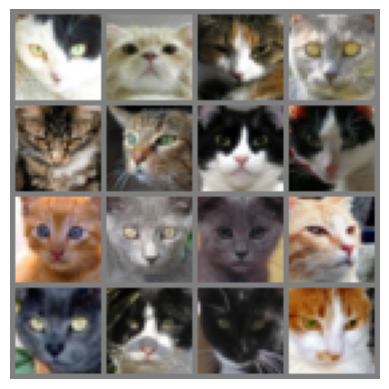

In [15]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [16]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [17]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 32, use_norm=False), # 32 -> 16
            DownBlock(32, 64),                # 16 -> 8
            DownBlock(64, 128),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_norm=True):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=not use_norm),
            # nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [18]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [19]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [20]:
def compute_gradient_penalty(real_images, fake_images):
    B = real_images.size(0)

    alpha = torch.rand(B, 1, 1, 1, device=device)
    interpolates = (alpha * real_images + (1 - alpha) * fake_images.detach()).requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(B, -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

In [21]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.9))

In [22]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 0.1706  G_loss: 0.0849  D(x): -0.319  D(G(z)): -0.189:   4%|▍         | 199/5000 [00:49<16:55,  4.73it/s]

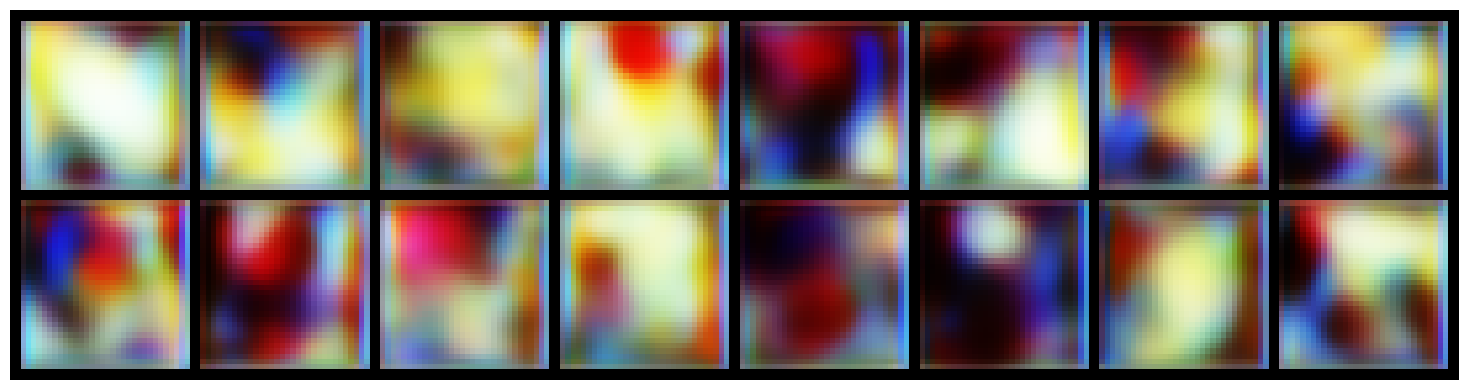

D_loss: -0.0961  G_loss: 0.3836  D(x): -0.267  D(G(z)): -0.405:   8%|▊         | 399/5000 [01:32<17:15,  4.45it/s]

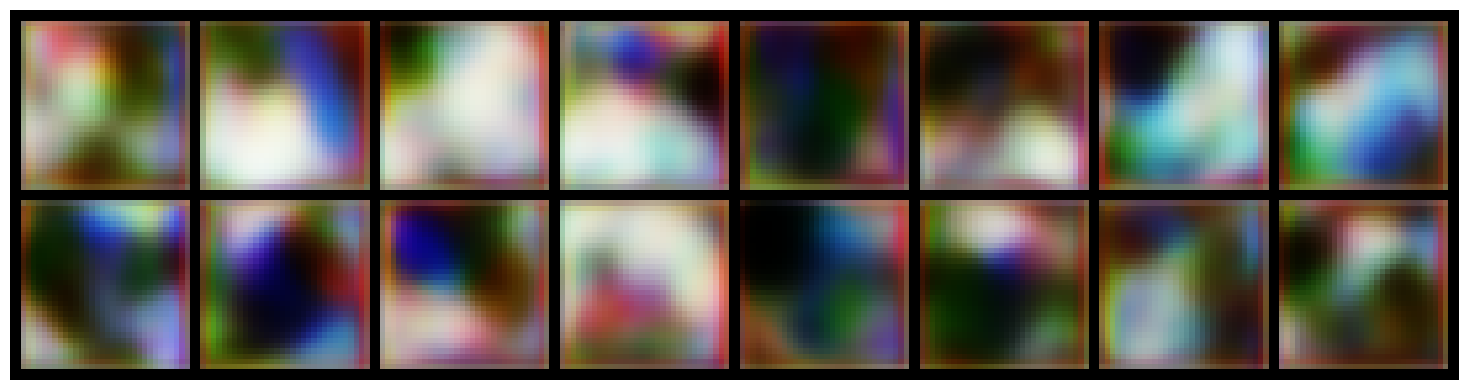

D_loss: -0.6019  G_loss: -1.8460  D(x): 3.579  D(G(z)): 2.954:  12%|█▏        | 599/5000 [02:00<06:02, 12.12it/s]

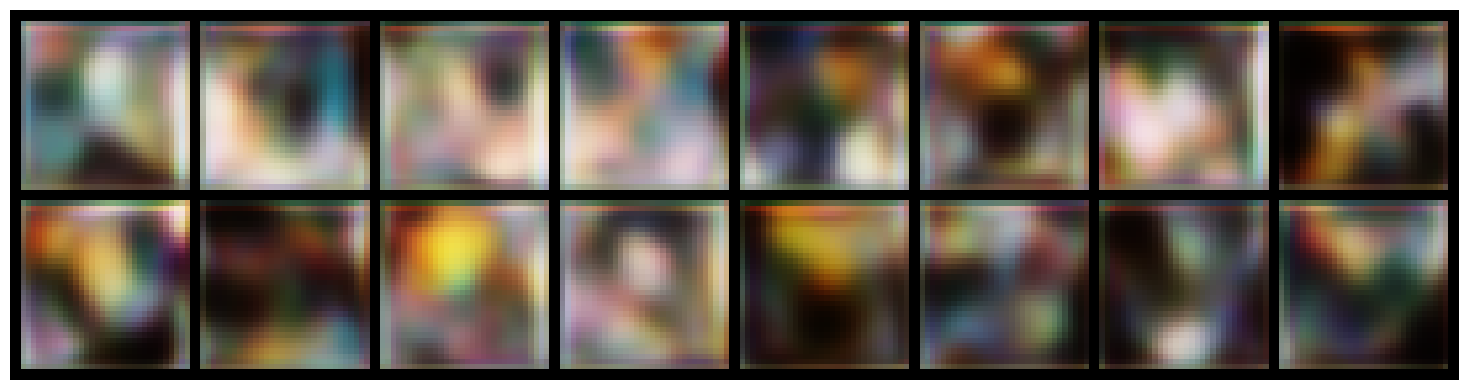

D_loss: -1.6244  G_loss: 0.1471  D(x): 3.028  D(G(z)): 1.363:  16%|█▌        | 799/5000 [02:17<05:31, 12.66it/s] 

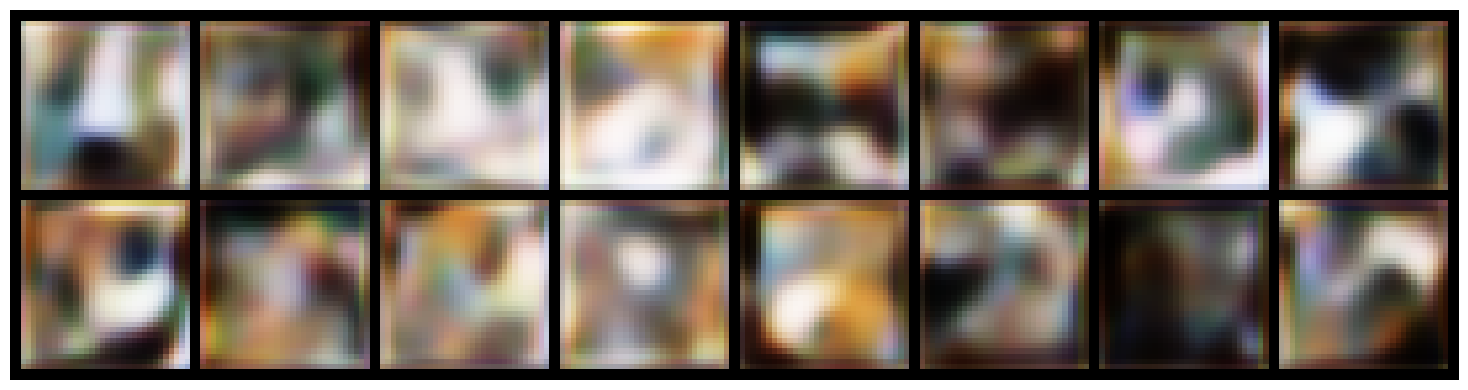

D_loss: -2.0153  G_loss: -1.3658  D(x): 5.442  D(G(z)): 3.276:  20%|█▉        | 999/5000 [02:34<05:57, 11.20it/s]

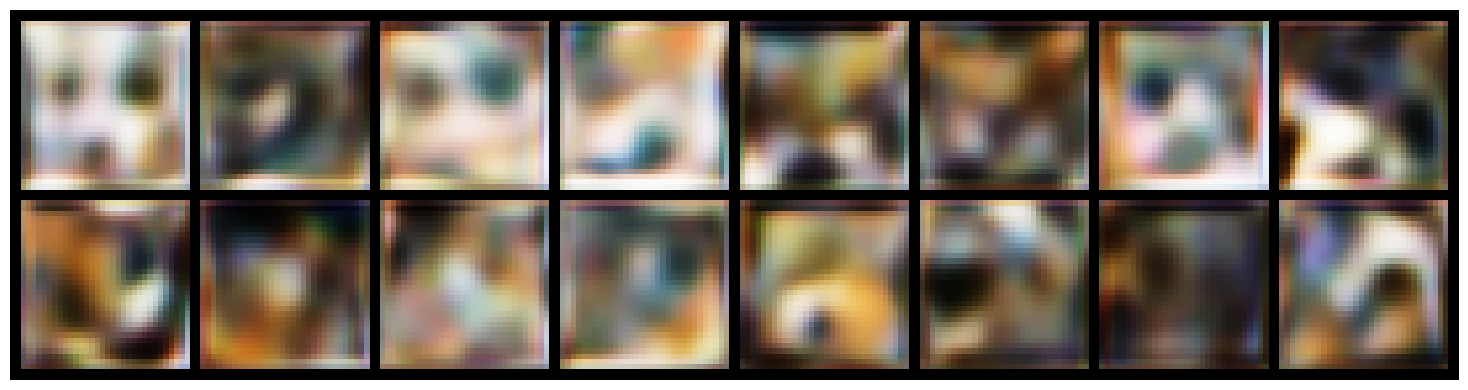

D_loss: -2.8204  G_loss: -6.1173  D(x): 10.289  D(G(z)): 7.231:  24%|██▍       | 1199/5000 [02:51<05:11, 12.19it/s]

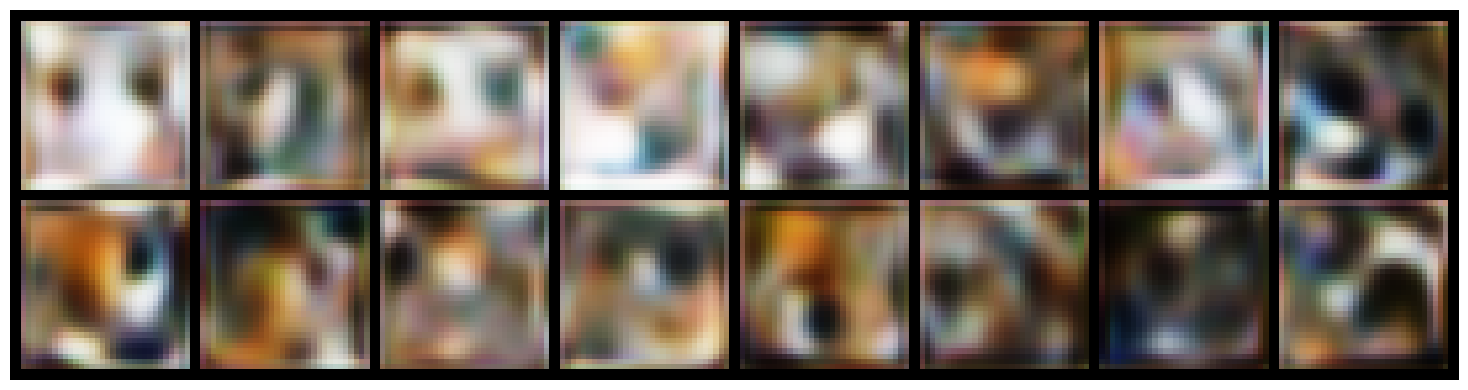

D_loss: -2.8329  G_loss: -10.0969  D(x): 13.990  D(G(z)): 10.948:  28%|██▊       | 1399/5000 [03:07<04:50, 12.41it/s]

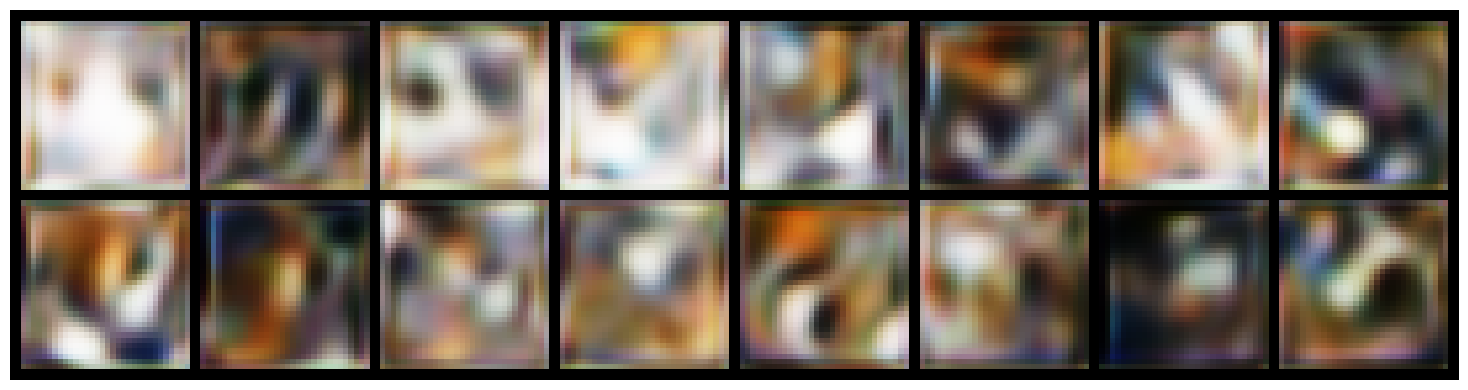

D_loss: -2.9037  G_loss: -11.8197  D(x): 17.375  D(G(z)): 14.237:  32%|███▏      | 1599/5000 [03:25<04:33, 12.41it/s]

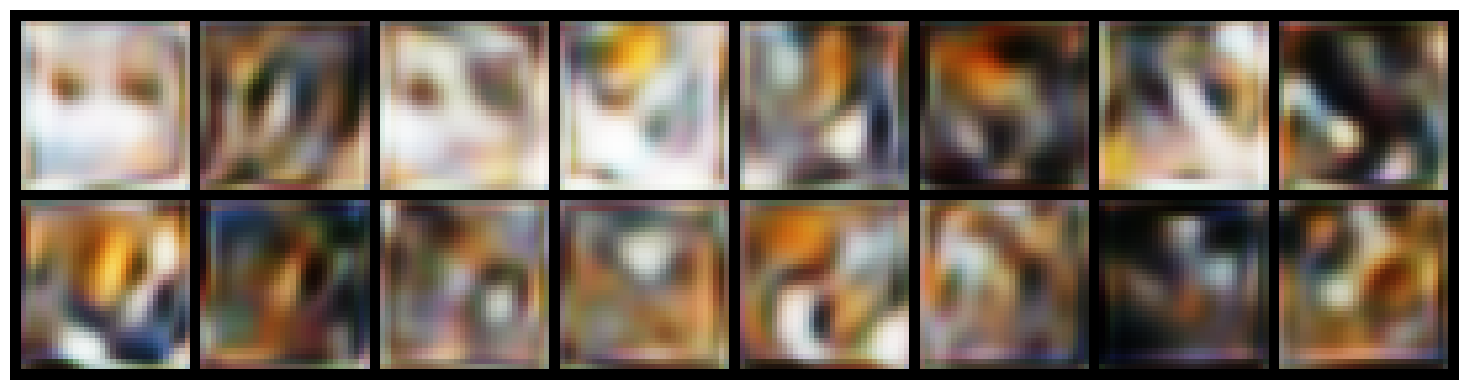

D_loss: -3.2319  G_loss: -12.1102  D(x): 14.034  D(G(z)): 10.633:  36%|███▌      | 1799/5000 [03:42<04:21, 12.22it/s]

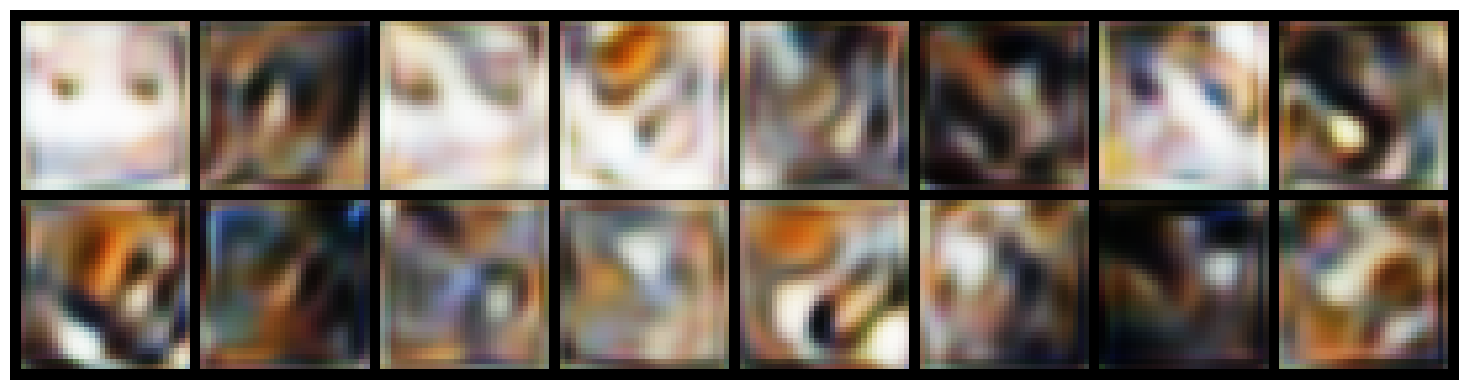

D_loss: -2.7215  G_loss: -13.3036  D(x): 16.354  D(G(z)): 13.487:  40%|███▉      | 1999/5000 [03:59<04:45, 10.51it/s]

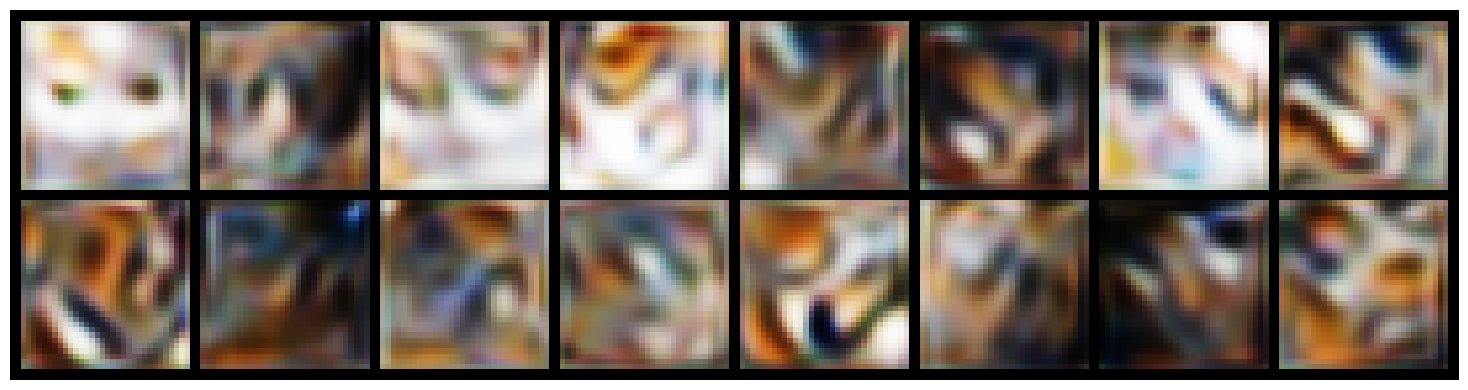

D_loss: -2.2854  G_loss: -15.4389  D(x): 17.699  D(G(z)): 15.195:  44%|████▍     | 2198/5000 [04:16<03:46, 12.38it/s]

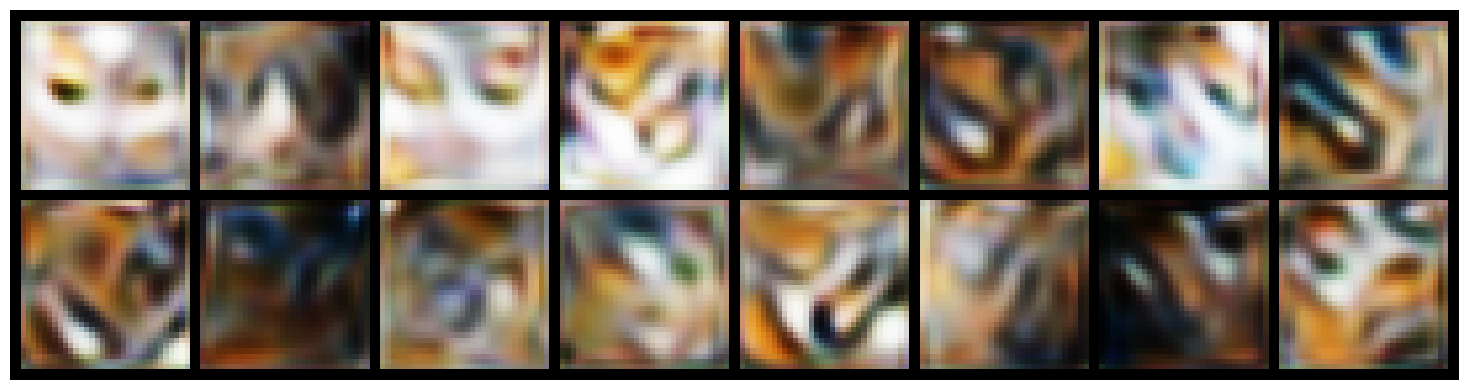

D_loss: -1.7513  G_loss: -13.1523  D(x): 15.784  D(G(z)): 13.860:  48%|████▊     | 2398/5000 [04:33<03:27, 12.53it/s]

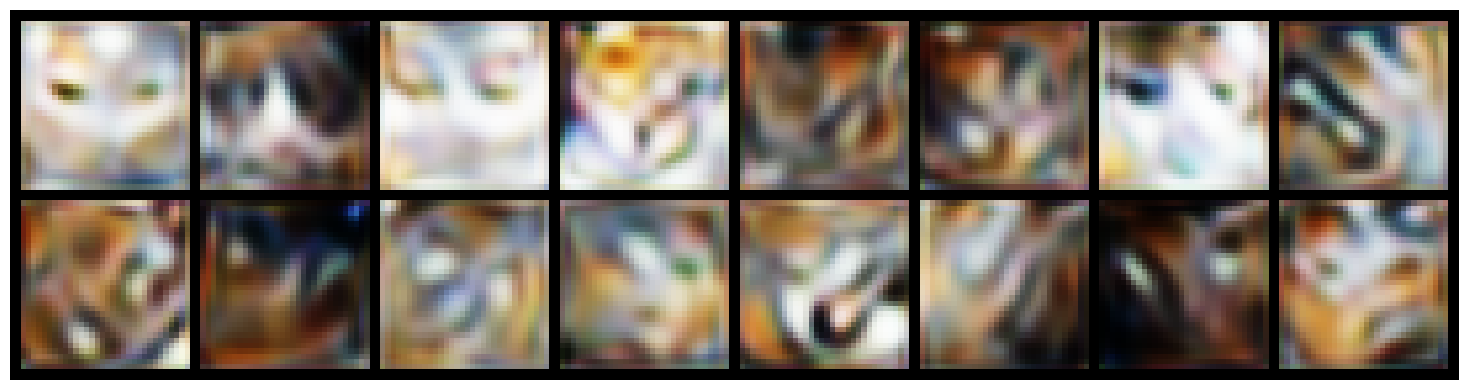

D_loss: -3.0642  G_loss: -14.4443  D(x): 16.952  D(G(z)): 13.652:  52%|█████▏    | 2598/5000 [04:50<03:13, 12.39it/s]

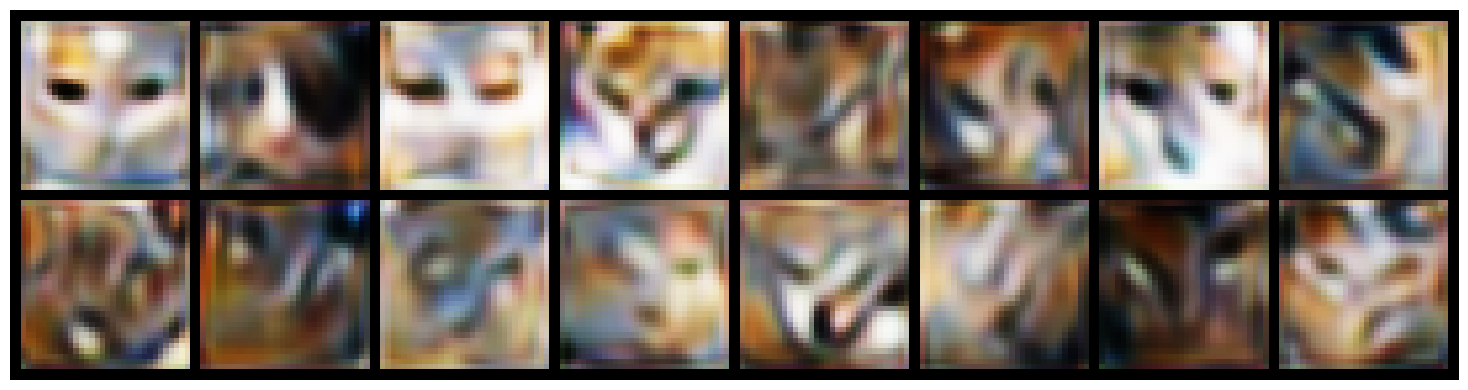

D_loss: -1.7296  G_loss: -17.3076  D(x): 18.221  D(G(z)): 16.323:  56%|█████▌    | 2798/5000 [05:07<02:57, 12.42it/s]

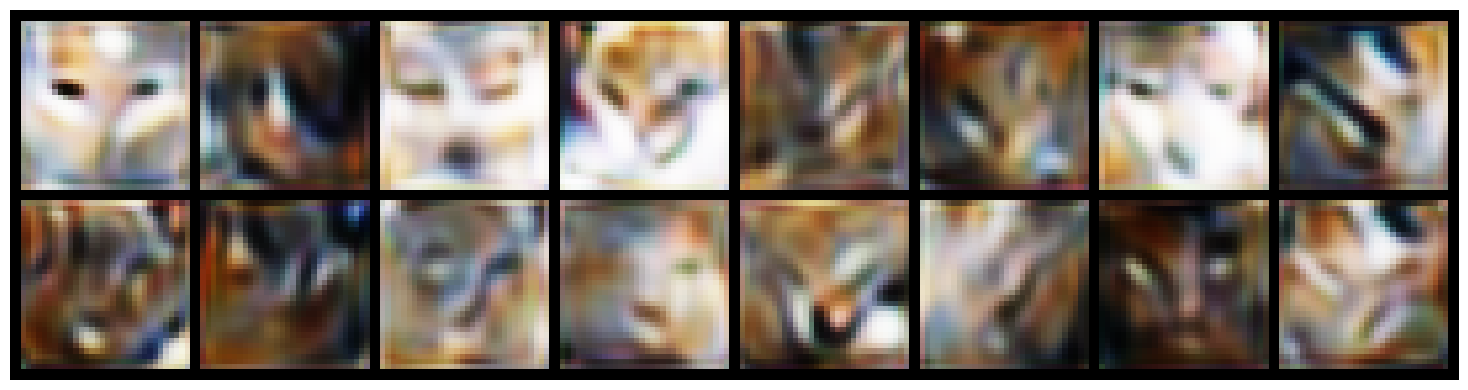

D_loss: -1.3838  G_loss: -17.4923  D(x): 19.281  D(G(z)): 17.783:  60%|█████▉    | 2999/5000 [05:25<03:42,  8.99it/s]

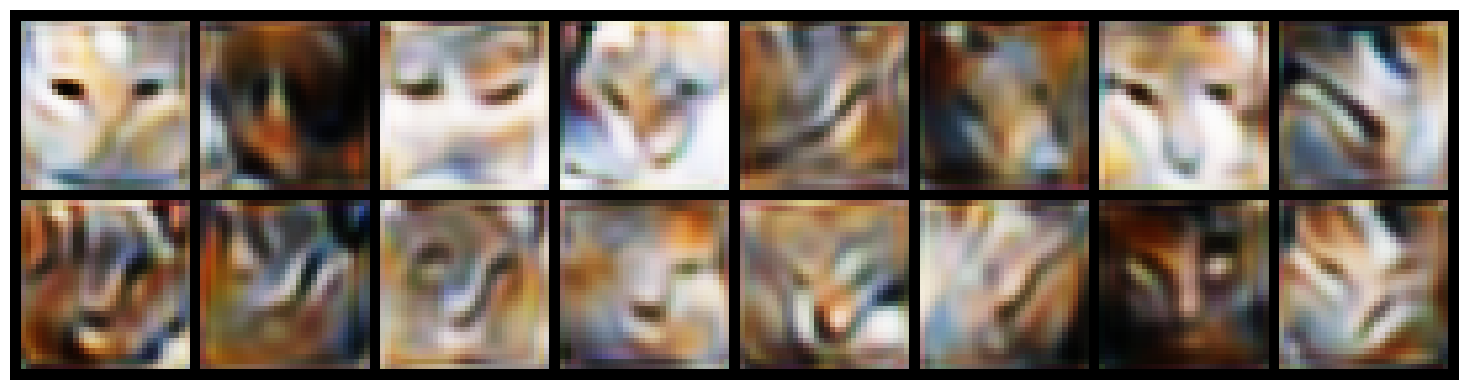

D_loss: -1.5875  G_loss: -19.2678  D(x): 20.066  D(G(z)): 18.401:  64%|██████▍   | 3199/5000 [05:42<02:30, 11.96it/s]

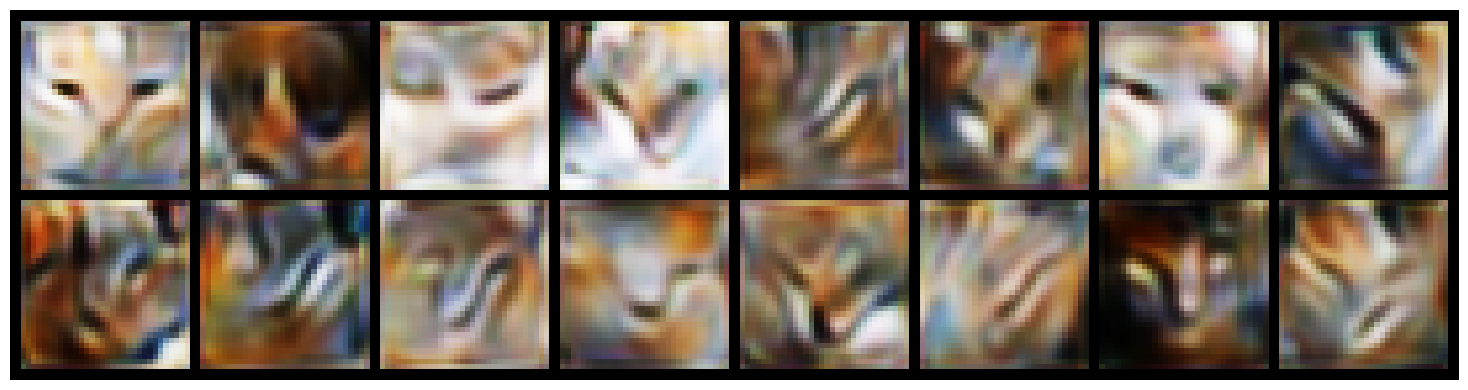

D_loss: -1.9575  G_loss: -17.6125  D(x): 19.020  D(G(z)): 16.991:  68%|██████▊   | 3398/5000 [05:59<02:13, 12.02it/s]

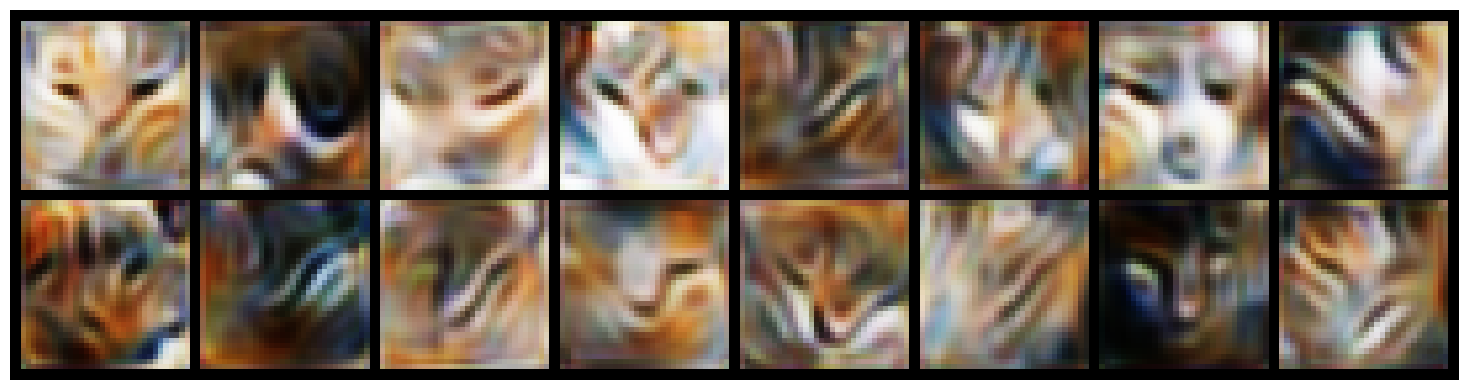

D_loss: -1.2843  G_loss: -17.1352  D(x): 17.677  D(G(z)): 16.348:  72%|███████▏  | 3598/5000 [06:16<01:53, 12.32it/s]

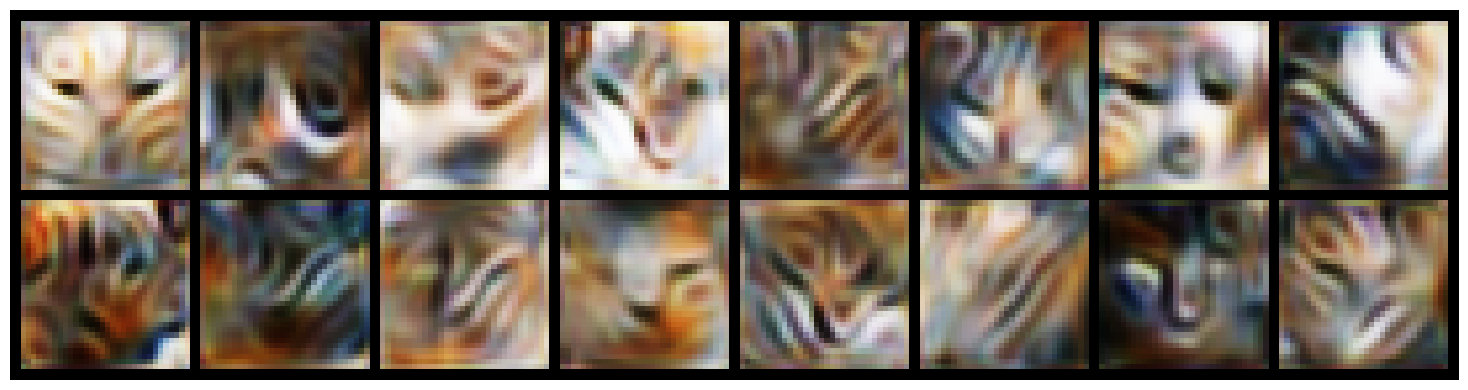

D_loss: -1.0538  G_loss: -17.1770  D(x): 18.148  D(G(z)): 17.050:  76%|███████▌  | 3799/5000 [06:34<01:36, 12.49it/s]

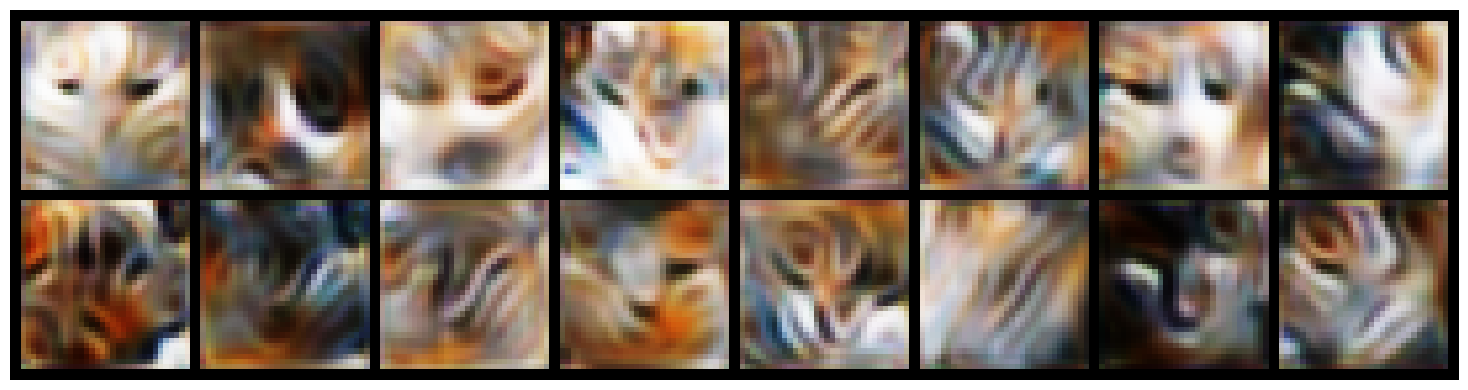

D_loss: -1.3493  G_loss: -17.7008  D(x): 19.254  D(G(z)): 17.840:  80%|███████▉  | 3998/5000 [06:51<01:31, 10.91it/s]

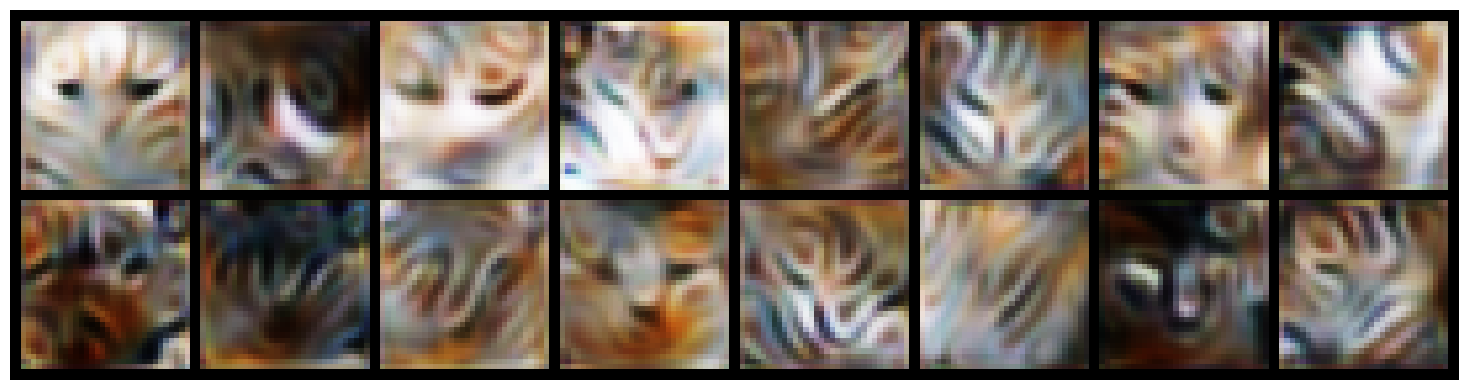

D_loss: -1.2087  G_loss: -14.7184  D(x): 16.430  D(G(z)): 15.169:  84%|████████▍ | 4199/5000 [07:08<01:04, 12.47it/s]

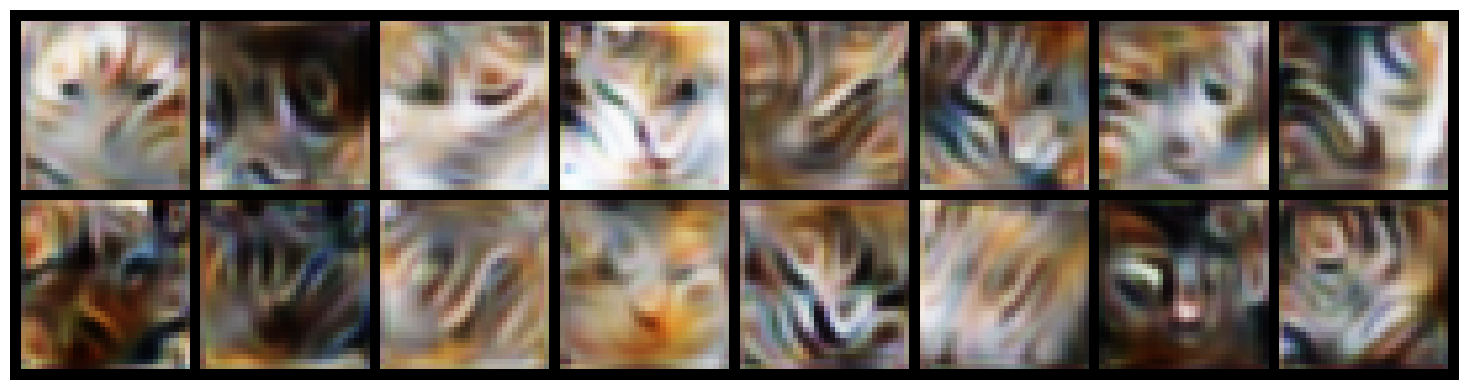

D_loss: -1.0235  G_loss: -14.3126  D(x): 15.317  D(G(z)): 14.254:  88%|████████▊ | 4399/5000 [07:25<00:50, 11.99it/s]

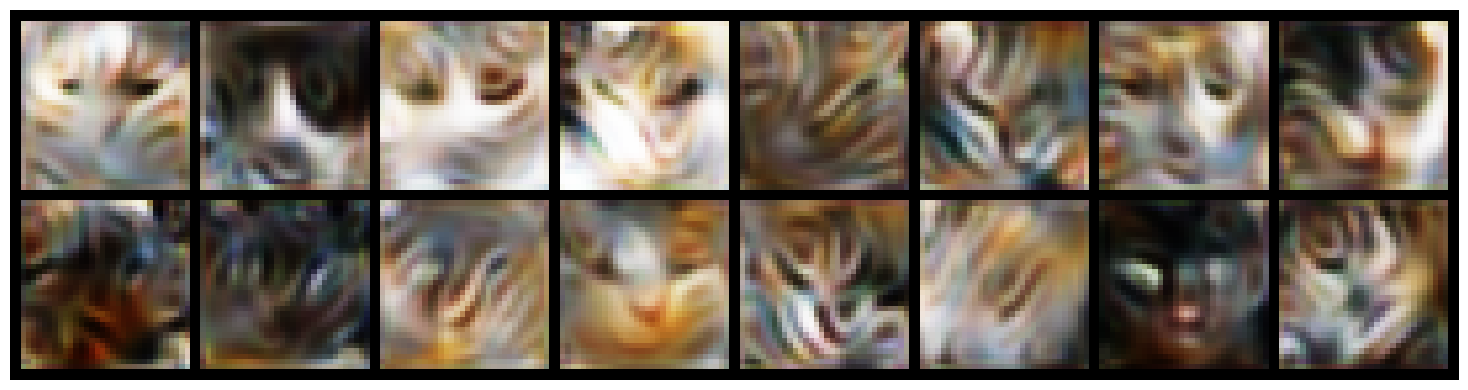

D_loss: -1.0537  G_loss: -11.9198  D(x): 11.934  D(G(z)): 10.847:  92%|█████████▏| 4599/5000 [07:43<00:32, 12.45it/s]

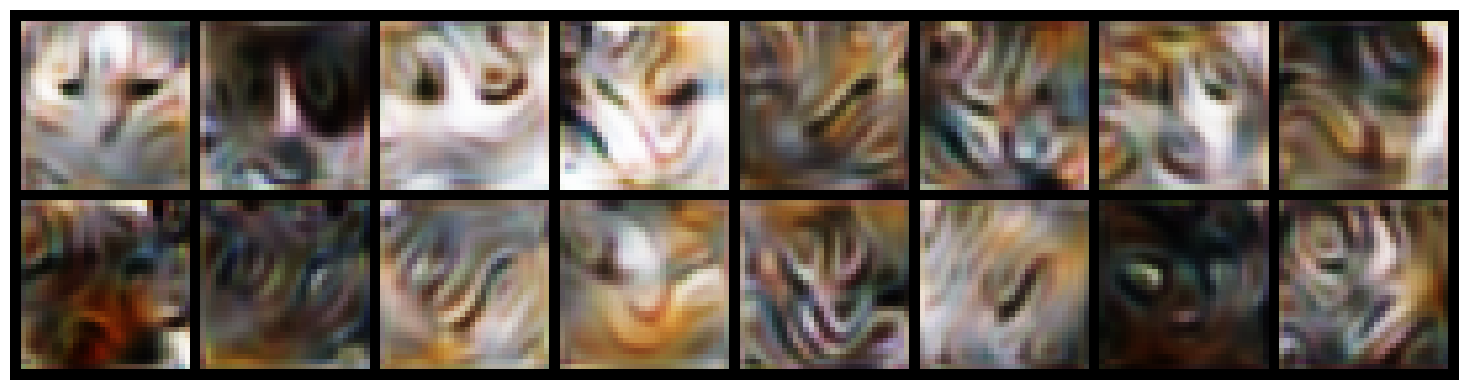

D_loss: -1.1115  G_loss: -9.7925  D(x): 11.632  D(G(z)): 10.454:  96%|█████████▌| 4799/5000 [08:00<00:16, 12.09it/s] 

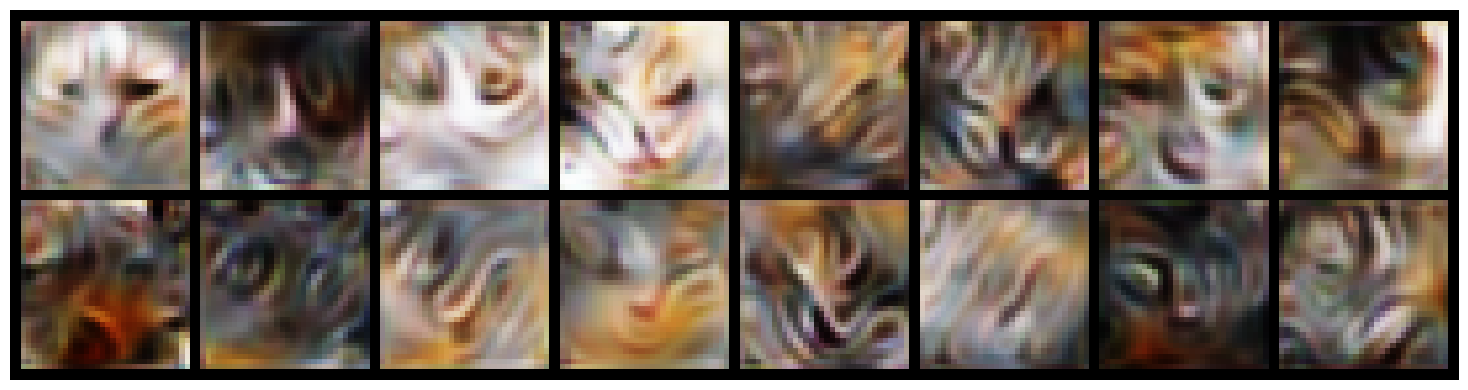

D_loss: -1.2021  G_loss: -10.6903  D(x): 11.907  D(G(z)): 10.669: 100%|█████████▉| 4999/5000 [08:18<00:00,  9.71it/s]

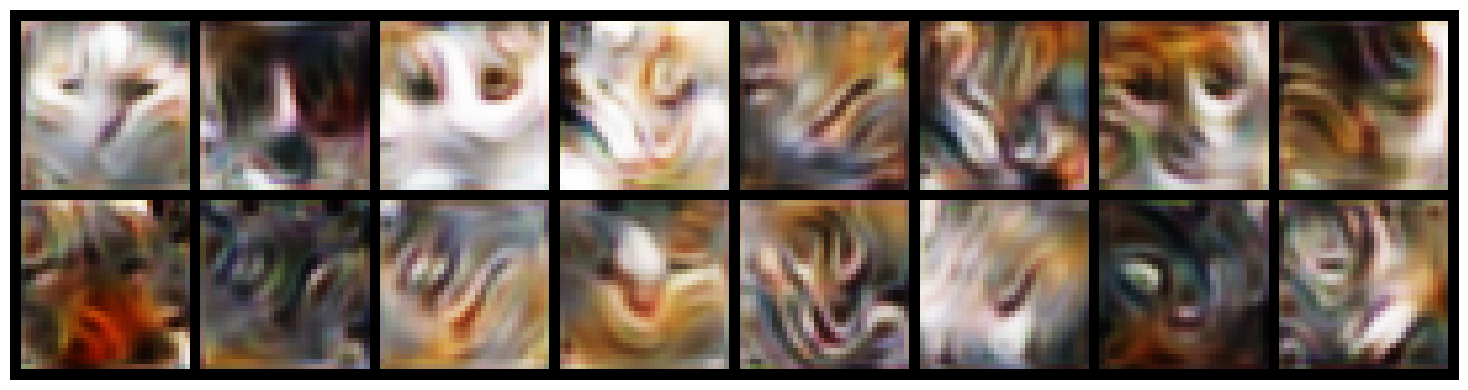

D_loss: -1.2021  G_loss: -10.6903  D(x): 11.907  D(G(z)): 10.669: 100%|██████████| 5000/5000 [08:18<00:00, 10.03it/s]


In [23]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
# real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
# fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="WGAN_GP")
loss_G = torch.tensor(0.0)

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    with torch.no_grad():
        fake_images = generator(z)

    d_real = discriminator(real_images)
    d_fake = discriminator(fake_images)

    gradient_penalty = compute_gradient_penalty(real_images, fake_images)

    loss_D = -torch.mean(d_real) + torch.mean(d_fake) + gradient_penalty * lambda_gp

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()

    ########## G Train ##########
    if step % 5 == 0:
        z = torch.randn(batch_size, latent_size, device=device)
        fake_images = generator(z)
        d_fake = discriminator(fake_images)
        loss_G = -torch.mean(d_fake)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)